# EDA — Exploración y calidad del dato (Tarea 1)

Nueve preguntas de negocio sobre el dataset sintético de retail, resueltas **una a una con
Spark SQL** sobre vistas temporales, cada una con su visualización. Es la Tarea 1 de
`CHALLENGE.md`.

El notebook **no calcula lógica de negocio**: la invoca. Toda la transformación vive en
`src/etl/` y este cuaderno consume lo que ya dejó `python -m src.etl.run_etl` en
`data/processed/` (ver `CLAUDE.md`, "Estilo"). Por eso se puede reejecutar entero en
minutos y cualquier cifra que salga aquí se puede recalcular desde un script.

**Requisito previo:** haber ejecutado el ETL.

```bash
python -m src.etl.run_etl
```

El cuaderno abre con un **reconocimiento de las tablas** (esquema, primeras filas y
verificación de las claves por las que se unen) y con el **Data Trust Score**; sólo
después vienen las nueve preguntas.

## Índice de preguntas

| # | Pregunta | Enlaza con |
| --- | --- | --- |
| Q1 | ¿Cómo se reparte la base de clientes y quién sostiene la facturación? | Segmentación, NBA |
| Q2 | ¿Qué se vende y qué peso tiene la marca blanca? | Catálogo del recomendador |
| Q3 | ¿Cómo evoluciona la venta y qué categorías son estacionales? | Candidatos por estacionalidad |
| Q4 | ¿Cómo es la cesta media y en qué se diferencia por canal? | Contexto de la cesta en curso |
| Q5 | ¿Qué categorías se compran juntas? | **Candidatos de co-compra (Fase 3)** |
| Q6 | ¿Cuál es el ciclo de recompra y cómo varía con el hogar? | **`due_for_repurchase` (Tarea 2)** |
| Q7 | ¿Qué diferencia a quien abandona y cuánto valor está en riesgo? | **Propensión de churn (Fase 4)** |
| Q8 | ¿Funcionan las promociones? | Feature de promoción del ranker |
| Q9 | ¿Cómo es el embudo online? | Señal de sesión del recomendador |

In [1]:
import sys
from pathlib import Path

# El notebook vive en notebooks/, pero los modulos y los datos cuelgan de la raiz del repo.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.eda import questions as q
from src.etl.schemas import read_processed
from src.etl.session import get_spark

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## Preparación: sesión de Spark y vistas temporales

`q.register_views` registra como vistas temporales las 7 tablas limpias y las 4 de
features. A partir de aquí, cada pregunta es una **función** de `src/eda/questions.py` que
hace su `spark.sql(...)` sobre esas vistas y devuelve un DataFrame.

Ese rodeo tiene un motivo: una consulta dentro de una celda no se puede comprobar más que
mirándola, y una que esté mal devuelve igualmente una tabla con pinta razonable. Sacadas a
funciones, las nueve preguntas están fijadas por
[`tests/test_eda_questions.py`](../tests/test_eda_questions.py) sobre un dataset diminuto
donde cada respuesta se calcula a mano. El cuaderno consulta y dibuja; no calcula.

In [2]:
spark = get_spark("eda-grocery", enable_ui=False)

# `register_views` lee las 11 tablas procesadas y las deja registradas como vistas
# temporales con su propio nombre: a partir de aqui cada pregunta es una funcion de
# `src/eda/questions.py` que hace su `spark.sql(...)` sobre ellas.
tables = q.register_views(spark, ROOT / "data" / "processed")

pd.DataFrame(
    [{"tabla": name, "filas": df.count(), "columnas": len(df.columns)}
     for name, df in tables.items()]
).set_index("tabla")

,filas,columnas
tabla,,
customers,20000,13
products,496,11
promotions,300,8
baskets,600174,12
basket_items,4292495,8
sessions,150000,8
session_events,1106140,4
rfm,20000,20
repurchase_features,689212,14


### Estilo de los gráficos

Una única paleta y un único tamaño base para las 9 figuras, para que el cuaderno se lea
como un informe y no como nueve cuadernos distintos.

In [3]:
sns.set_theme(style="whitegrid", font_scale=0.95)
PALETTE = ["#2E6E8E", "#E1812C", "#3A923A", "#C03D3E", "#9372B2", "#7F7F7F"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["figure.autolayout"] = False

EUR = "{:,.0f} €"


def money(value: float) -> str:
    """Formatea un importe en euros con separador de miles a la espanola."""
    return EUR.format(value).replace(",", ".")


def annotate_bars(ax, fmt="{:.1f}", padding=3, fontsize=8):
    """Escribe el valor encima de cada barra: evita tener que leer el eje."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=fontsize)

---

## Reconocimiento: qué hay en cada tabla y cómo se enlazan

Antes de preguntarle nada al dato conviene mirarlo: qué columnas tiene cada tabla, qué
representa una fila, y por dónde se unen unas con otras. Esta sección no calcula nada de
negocio — es el mapa que hace falta para leer todo lo que viene después.

Las 11 vistas registradas son las **7 tablas limpias** (misma estructura que `data/raw`,
más columnas testigo de lo corregido) y las **4 tablas de features** que construyó la
Fase 2.

### Inventario: grano y volumen

El **grano** es lo que representa una fila. Es el dato que más se malinterpreta al
empezar: confundir el grano de `baskets` (un ticket) con el de `basket_items` (una línea
de ticket) es la vía rápida a contar la facturación varias veces.

La columna `clave_unica` no se declara, se **comprueba**: cuenta filas contra
combinaciones distintas de la clave.

In [4]:
GRANO = {
    "customers":           (["customer_id"],               "Un cliente"),
    "products":            (["product_id"],                "Un producto del surtido"),
    "promotions":          (["promotion_id"],              "Una promoción con su ventana de vigencia"),
    "baskets":             (["basket_id"],                 "Un ticket (cabecera)"),
    "basket_items":        (["basket_id", "product_id"],   "Una línea de ticket"),
    "sessions":            (["session_id"],                "Una sesión online"),
    "session_events":      (["session_id", "product_id", "event_type", "event_timestamp"],
                                                           "Un evento dentro de una sesión"),
    "rfm":                 (["customer_id"],               "Un cliente con su RFM y su segmento"),
    "repurchase_features": (["customer_id", "category"],   "Un cliente y una categoría"),
    "affinity_category":   (["antecedent", "consequent"],  "Un par ordenado de categorías"),
    "affinity_product":    (["antecedent", "consequent"],  "Un par ordenado de productos"),
}

inventario = []
for nombre, (clave, grano) in GRANO.items():
    df = tables[nombre]
    filas = df.count()
    inventario.append({
        "tabla": nombre,
        "grano": grano,
        "clave": " + ".join(clave),
        "filas": filas,
        "columnas": len(df.columns),
        "clave_unica": df.select(*clave).distinct().count() == filas,
    })

inventario = pd.DataFrame(inventario).set_index("tabla")
inventario

,grano,clave,filas,columnas,clave_unica
tabla,,,,,
customers,Un cliente,customer_id,20000,13,True
products,Un producto del surtido,product_id,496,11,True
promotions,Una promoción con su ventana de vigencia,promotion_id,300,8,True
baskets,Un ticket (cabecera),basket_id,600174,12,True
basket_items,Una línea de ticket,basket_id + product_id,4292495,8,True
sessions,Una sesión online,session_id,150000,8,True
session_events,Un evento dentro de una sesión,session_id + product_id + event_type + event_t...,1106140,4,True
rfm,Un cliente con su RFM y su segmento,customer_id,20000,20,True
repurchase_features,Un cliente y una categoría,customer_id + category,689212,14,True


Las 11 claves son únicas, incluida la de `basket_items`: tras la limpieza hay **una sola
línea por cesta y producto**, que es el supuesto del que depende toda la afinidad de cesta
(Q5). Sobre el dato crudo esa comprobación fallaba en 64.512 filas.

### Esquema y primeras filas

`DESCRIBE TABLE` sobre cada vista, más una muestra. Las tablas limpias llevan columnas que
no existen en `data/raw`: son el rastro de lo que corrigió el ETL (`*_raw` guarda el valor
original, `*_is_missing` / `*_corrected` marcan la fila tocada). Están documentadas en
`DATA_SPEC.md`, sección "Tablas de `data/processed/`".

In [5]:
from IPython.display import Markdown, display


def vistazo(nombre: str, n: int = 5, columnas: list[str] | None = None) -> None:
    """Muestra el esquema y las primeras filas de una vista registrada.

    `columnas` recorta la muestra en las tablas anchas, donde ver 20 columnas a la vez no
    aporta nada; el esquema siempre se muestra entero.
    """
    df = tables[nombre]
    display(Markdown(f"**`{nombre}`** — {df.count():,} filas · {len(df.columns)} columnas".replace(",", ".")))

    esquema = spark.sql(f"DESCRIBE TABLE {nombre}").toPandas()
    esquema = esquema[["col_name", "data_type"]].rename(
        columns={"col_name": "columna", "data_type": "tipo"}
    )
    display(esquema.set_index("columna"))

    seleccion = ", ".join(columnas) if columnas else "*"
    display(spark.sql(f"SELECT {seleccion} FROM {nombre} LIMIT {n}").toPandas())

#### Dimensiones: quién compra, qué se vende y qué está en promoción

In [6]:
vistazo("customers")
vistazo("products")
vistazo("promotions")

**`customers`** — 20.000 filas · 13 columnas

,tipo
columna,
customer_id,string
signup_date,date
signup_date_raw,date
signup_date_corrected,boolean
country,string
city,string
city_is_missing,boolean
household_size_est,int
loyalty_tier,string


,customer_id,signup_date,signup_date_raw,signup_date_corrected,country,city,city_is_missing,household_size_est,loyalty_tier,preferred_channel,churn_label,first_purchase_date,last_purchase_date
0,C000001,2025-07-09,2025-07-09,False,Espana,Zaragoza,False,2,silver,store,False,2025-07-31,2025-12-19
1,C000002,2021-01-28,2021-01-28,False,Espana,Zaragoza,False,1,gold,web,False,2024-01-04,2025-12-27
2,C000003,2023-08-31,2023-08-31,False,Espana,Salamanca,False,3,silver,web,False,2024-01-09,2025-12-13
3,C000004,2025-07-11,2025-07-11,False,Espana,Madrid,False,1,silver,app,True,None,None
4,C000005,2022-07-02,2022-07-02,False,Espana,Valencia,False,6,bronze,store,True,2024-01-11,2025-07-17


**`products`** — 496 filas · 11 columnas

,tipo
columna,
product_id,string
department,string
category,string
category_raw,string
brand,string
brand_is_missing,boolean
is_private_label,boolean
is_perishable,boolean
unit_price,double


,product_id,department,category,category_raw,brand,brand_is_missing,is_private_label,is_perishable,unit_price,pack_size,typical_repurchase_days
0,P00001,Frescos,Leche,Leche,Jordán y asociados S.C.P,False,False,True,0.88,1,6
1,P00002,Frescos,Leche,Leche,Farmaceútica Vera & Asociados S.L.N.E,False,False,True,1.08,12,6
2,P00003,Frescos,Leche,Leche,Infraestructuras Carlos S.L.N.E,False,False,True,1.24,4,6
3,P00004,Frescos,Leche,Leche,Comercial Bru y asociados S.L.L.,False,False,True,0.90,1,6
4,P00005,Frescos,Leche,Leche,Suministros Pujol y asociados S.A.T.,False,False,True,0.96,2,6


**`promotions`** — 300 filas · 8 columnas

,tipo
columna,
promotion_id,string
product_id,string
promo_type,string
discount_value,double
start_date,date
end_date,date
date_range_invalid,boolean
duration_days,int


,promotion_id,product_id,promo_type,discount_value,start_date,end_date,date_range_invalid,duration_days
0,PR0001,P00032,2x1,0.50,2024-06-11,2024-06-27,False,17
1,PR0002,P00360,coupon,2.00,2024-01-15,2024-02-13,False,30
2,PR0003,P00032,coupon,1.00,2024-06-04,2024-07-02,False,29
3,PR0004,P00163,discount_pct,0.35,2025-09-14,2025-10-08,False,25
4,PR0005,P00333,discount_pct,0.35,2025-05-31,2025-06-20,False,21


#### Hechos: el ticket y su detalle

`baskets` es la cabecera y `basket_items` el detalle. Ojo a `total_amount`: en la tabla
limpia **ya no es el valor original**, sino el recalculado desde las líneas;
`total_amount_raw` conserva el que venía en el fichero. La diferencia entre ambos es lo
que destapa los outliers de importe.

In [7]:
vistazo("baskets")
vistazo("basket_items")

**`baskets`** — 600.174 filas · 12 columnas

,tipo
columna,
basket_id,string
customer_id,string
channel,string
basket_date,timestamp
basket_day,date
store_id,string
total_amount,double
total_amount_raw,double
total_amount_is_outlier,boolean


,basket_id,customer_id,channel,basket_date,basket_day,store_id,total_amount,total_amount_raw,total_amount_is_outlier,n_lines,n_units,is_anonymous
0,B0000004,None,store,2024-01-01 12:26:39,2024-01-01,S011,64.44,64.44,False,10,15,True
1,B0000011,None,store,2024-01-01 12:10:24,2024-01-01,S040,21.78,21.78,False,3,9,True
2,B0000017,None,web,2024-01-01 14:03:41,2024-01-01,None,9.21,9.21,False,2,2,True
3,B0000020,None,web,2024-01-01 17:08:09,2024-01-01,None,38.17,38.17,False,6,12,True
4,B0000021,None,store,2024-01-01 17:51:26,2024-01-01,S017,4.73,4.73,False,2,4,True


**`basket_items`** — 4.292.495 filas · 8 columnas

,tipo
columna,
basket_id,string
product_id,string
quantity,int
unit_price_paid,double
promotion_id,string
line_amount,double
is_promo,boolean
quantity_sign_corrected,boolean


,basket_id,product_id,quantity,unit_price_paid,promotion_id,line_amount,is_promo,quantity_sign_corrected
0,B0000828,P00473,2,2.85,PR0286,5.70,True,False
1,B0001190,P00297,4,3.08,PR0153,12.32,True,False
2,B0001654,P00473,2,2.85,PR0286,5.70,True,False
3,B0001682,P00473,2,2.85,PR0286,5.70,True,False
4,B0001907,P00473,2,2.85,PR0286,5.70,True,False


#### Canal online: la sesión y sus eventos

In [8]:
vistazo("sessions")
vistazo("session_events")

**`sessions`** — 150.000 filas · 8 columnas

,tipo
columna,
session_id,string
customer_id,string
session_date,timestamp
session_day,date
device_type,string
converted,boolean
basket_id,string
is_anonymous,boolean


,session_id,customer_id,session_date,session_day,device_type,converted,basket_id,is_anonymous
0,S0000001,None,2024-01-01 17:00:27,2024-01-01,tablet,True,B0000020,True
1,S0000002,C000658,2024-01-01 13:24:21,2024-01-01,mobile,True,B0000047,False
2,S0000003,C000791,2024-01-01 16:26:33,2024-01-01,desktop,True,B0000053,False
3,S0000004,C000883,2024-01-01 17:25:43,2024-01-01,mobile,True,B0000054,False
4,S0000005,C002057,2024-01-01 18:40:57,2024-01-01,mobile,True,B0000089,False


**`session_events`** — 1.106.140 filas · 4 columnas

,tipo
columna,
session_id,string
product_id,string
event_type,string
event_timestamp,timestamp


,session_id,product_id,event_type,event_timestamp
0,S0000003,P00312,view,2024-01-01 16:35:03
1,S0000004,P00161,view,2024-01-01 17:45:05
2,S0000006,P00082,add_to_cart,2024-01-01 23:49:05
3,S0000006,P00021,add_to_cart,2024-01-01 23:55:04
4,S0000007,P00181,add_to_cart,2024-01-01 21:51:17


#### Features de la Fase 2

Estas cuatro no vienen del generador: las construye el ETL y son la materia prima de las
Fases 3 y 4.

In [9]:
vistazo("rfm", columnas=["customer_id", "recency_days", "frequency", "monetary",
                         "avg_ticket", "rfm_score", "rfm_segment"])
vistazo("repurchase_features", columnas=["customer_id", "category", "last_purchase_date",
                                         "observed_repurchase_days", "expected_repurchase_days",
                                         "days_since_last_purchase", "due_for_repurchase"])
vistazo("affinity_category", columnas=["antecedent", "consequent", "n_baskets_both",
                                       "support", "confidence", "lift"])
vistazo("affinity_product", columnas=["antecedent", "consequent", "n_baskets_both",
                                      "lift", "rank"])

**`rfm`** — 20.000 filas · 20 columnas

,tipo
columna,
customer_id,string
loyalty_tier,string
signup_date,date
churn_label,boolean
last_purchase_date,date
first_purchase_date,date
frequency,int
monetary,double
avg_ticket,double


,customer_id,recency_days,frequency,monetary,avg_ticket,rfm_score,rfm_segment
0,C015865,607,1,0.20,0.20,111,Hibernando
1,C017773,551,1,0.20,0.20,111,Hibernando
2,C000609,423,1,0.88,0.88,111,Hibernando
3,C008329,293,1,0.88,0.88,111,Hibernando
4,C019754,74,1,0.88,0.88,211,Hibernando


**`repurchase_features`** — 689.212 filas · 14 columnas

,tipo
columna,
customer_id,string
category,string
last_purchase_date,date
first_purchase_date,date
n_purchase_days,int
observed_repurchase_days,double
stddev_gap_days,double
typical_repurchase_days,int
household_factor,double


...

,tipo
columna,
antecedent,string
consequent,string
total_baskets,int
n_baskets_antecedent,bigint
n_baskets_consequent,bigint
n_baskets_both,bigint
support,double
confidence,double
lift,double


,antecedent,consequent,n_baskets_both,support,confidence,lift
0,Arena para gato,Comida para gato,6689,0.011145,0.537960,21.2163
1,Comida para gato,Arena para gato,6689,0.011145,0.439545,21.2163
2,Cava y espumosos,Turron y mazapan,2476,0.004125,0.267907,17.8142
3,Turron y mazapan,Cava y espumosos,2476,0.004125,0.274319,17.8142
4,Panales,Toallitas humedas,14853,0.024748,0.690388,16.3240


**`affinity_product`** — 9.795 filas · 11 columnas

,tipo
columna,
antecedent,string
consequent,string
total_baskets,int
n_baskets_antecedent,bigint
n_baskets_consequent,bigint
n_baskets_both,bigint
support,double
confidence,double
lift,double


,antecedent,consequent,n_baskets_both,lift,rank
0,P00455,P00442,52,37.9096,1
1,P00442,P00455,52,37.9096,1
2,P00403,P00409,59,32.0939,1
3,P00409,P00403,59,32.0939,1
4,P00453,P00447,111,27.1284,1


### Estadísticos de las columnas numéricas

`summary()` sobre lo que se va a agregar después. Sirve para detectar de un vistazo rangos
imposibles, colas largas y unidades que no son las que uno creía.

In [10]:
display(Markdown("**`baskets`** — importe y tamaño del ticket"))
display(
    spark.sql("SELECT total_amount, n_lines, n_units FROM baskets")
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
    .toPandas().set_index("summary")
)

display(Markdown("**`basket_items`** — unidades y precio pagado por línea"))
display(
    spark.sql("SELECT quantity, unit_price_paid, line_amount FROM basket_items")
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
    .toPandas().set_index("summary")
)

display(Markdown("**`products`** — precio de tarifa y ciclo de reposición"))
display(
    spark.sql("SELECT unit_price, pack_size, typical_repurchase_days FROM products")
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
    .toPandas().set_index("summary")
)

**`baskets`** — importe y tamaño del ticket

,total_amount,n_lines,n_units
summary,,,
count,600174,600174,600174
mean,39.39713233162109,7.152084228906951,11.190299813054214
stddev,48.708018503792665,7.421452993403076,11.821518221218037
min,0.2,1,1
25%,9.66,3,4
50%,21.83,5,7
75%,48.21,9,14
max,519.53,58,105


**`basket_items`** — unidades y precio pagado por línea

,quantity,unit_price_paid,line_amount
summary,,,
count,4292495,4292495,4292495
mean,1.5646208091098535,3.5261998604552494,5.508482712273
stddev,0.827607374263764,2.968340748418002,5.991565220806489
min,1,0.2,0.2
25%,1,1.61,2.22
50%,1,2.63,3.59
75%,2,4.23,6.61
max,4,24.88,99.52


**`products`** — precio de tarifa y ciclo de reposición

,unit_price,pack_size,typical_repurchase_days
summary,,,
count,496,496,496
mean,5.0492338709677425,4.110887096774194,43.0
stddev,4.591115950886757,3.9170441364663087,59.24453689172658
min,0.62,1,4
25%,2.1,1,12
50%,3.3,2,25
75%,6.21,6,45
max,24.88,12,330


Tres cosas que se leen aquí y condicionan lo que viene:

- **`quantity` tiene mínimo 1.** En el crudo había 17.253 líneas negativas; ya no queda
  ninguna. Lo mismo con `unit_price_paid`, que nunca es 0.
- **`total_amount` tiene una cola larga por la derecha** — la media queda por encima de la
  mediana. Son cestas grandes legítimas, no los outliers inyectados: esos se detectaron
  comparando la cabecera con el detalle, no por el importe en sí (ver `docs/CLEANING.md`).
- **`typical_repurchase_days` va de 4 a 330 días.** Ese rango es lo que hace que un único
  umbral de "toca reponer" no valga para todo el surtido, y por eso `due_for_repurchase`
  trabaja por categoría (Q6).

### Por dónde se unen las tablas

El modelo es un copo de nieve con dos hechos (`baskets` / `basket_items`) y un satélite
online (`sessions` / `session_events`):

```
                 customers ──┬── baskets ──── basket_items ──┬── products
                             │      │                        │      │
                             │      └────── sessions         │  promotions
                             │                  │            │
                             └──────────────────┘       session_events ──┘

  rfm ── customer_id ─→ customers
  repurchase_features ── customer_id ─→ customers · category ─→ products.category
  affinity_category ── antecedent/consequent ─→ products.category
  affinity_product  ── antecedent/consequent ─→ products.product_id
```

En vez de dar la lista por buena, la celda siguiente **comprueba cada relación**: cuántas
filas tienen la clave informada y cuántas de esas encuentran pareja al otro lado. Un
`pct_match` por debajo de 100 significa una clave huérfana, y eso rompería cualquier
`JOIN` posterior sin avisar.

Ojo con la diferencia entre **nulo** y **huérfano**: `baskets.customer_id` está a nulo en
un 3 % de los tickets, pero eso son compras anónimas legítimas, no un fallo de integridad.
Por eso la comprobación mide el emparejamiento sólo sobre las filas con la clave
informada, y muestra aparte cuántas la traen a nulo.

In [11]:
RELACIONES = [
    # (tabla origen, columna, tabla destino, columna, cardinalidad)
    ("basket_items",        "basket_id",    "baskets",    "basket_id",    "N:1"),
    ("basket_items",        "product_id",   "products",   "product_id",   "N:1"),
    ("basket_items",        "promotion_id", "promotions", "promotion_id", "N:1 opcional"),
    ("baskets",             "customer_id",  "customers",  "customer_id",  "N:1 opcional"),
    ("sessions",            "customer_id",  "customers",  "customer_id",  "N:1 opcional"),
    ("sessions",            "basket_id",    "baskets",    "basket_id",    "1:1 opcional"),
    ("session_events",      "session_id",   "sessions",   "session_id",   "N:1"),
    ("session_events",      "product_id",   "products",   "product_id",   "N:1"),
    ("promotions",          "product_id",   "products",   "product_id",   "N:1"),
    ("rfm",                 "customer_id",  "customers",  "customer_id",  "1:1"),
    ("repurchase_features", "customer_id",  "customers",  "customer_id",  "N:1"),
    ("repurchase_features", "category",     "products",   "category",     "N:1"),
    ("affinity_category",   "antecedent",   "products",   "category",     "N:1"),
    ("affinity_product",    "antecedent",   "products",   "product_id",   "N:1"),
]

integridad = []
for origen, col_o, destino, col_d, cardinalidad in RELACIONES:
    fila = spark.sql(f"""
        SELECT
            COUNT(*)                                              AS filas,
            SUM(CASE WHEN o.{col_o} IS NULL THEN 1 ELSE 0 END)    AS clave_nula,
            COUNT(DISTINCT o.{col_o})                             AS claves_distintas,
            SUM(CASE WHEN o.{col_o} IS NOT NULL AND d.{col_d} IS NULL THEN 1 ELSE 0 END)
                                                                  AS huerfanas
        FROM {origen} o
        LEFT JOIN (SELECT DISTINCT {col_d} FROM {destino}) d
               ON d.{col_d} = o.{col_o}
    """).collect()[0]

    informadas = fila["filas"] - fila["clave_nula"]
    integridad.append({
        "relación": f"{origen}.{col_o} → {destino}.{col_d}",
        "cardinalidad": cardinalidad,
        "filas": fila["filas"],
        "clave nula": fila["clave_nula"],
        "claves distintas": fila["claves_distintas"],
        "huérfanas": fila["huerfanas"],
        "% match": round(100 * (informadas - fila["huerfanas"]) / informadas, 2) if informadas else None,
    })

integridad = pd.DataFrame(integridad).set_index("relación")
integridad

,cardinalidad,filas,clave nula,claves distintas,huérfanas,% match
relación,,,,,,
basket_items.basket_id → baskets.basket_id,N:1,4292495,0,600174,0,100.0
basket_items.product_id → products.product_id,N:1,4292495,0,496,0,100.0
basket_items.promotion_id → promotions.promotion_id,N:1 opcional,4292495,4083534,299,0,100.0
baskets.customer_id → customers.customer_id,N:1 opcional,600174,18000,19225,0,100.0
sessions.customer_id → customers.customer_id,N:1 opcional,150000,34650,19701,0,100.0
sessions.basket_id → baskets.basket_id,1:1 opcional,150000,97500,52500,0,100.0
session_events.session_id → sessions.session_id,N:1,1106140,0,149960,0,100.0
session_events.product_id → products.product_id,N:1,1106140,0,496,0,100.0
promotions.product_id → products.product_id,N:1,300,0,195,0,100.0


In [12]:
rotas = integridad[integridad["huérfanas"] > 0]
if rotas.empty:
    print(f"Las {len(integridad)} relaciones resuelven al 100 %: no hay ni una clave huérfana.")
else:
    print("Relaciones con claves huérfanas:")
    display(rotas)

nulos = integridad[integridad["clave nula"] > 0]
print("\nClaves opcionales (nulo legítimo, no es un fallo de integridad):")
display(nulos[["clave nula", "filas"]].assign(
    pct=lambda d: (100 * d["clave nula"] / d["filas"]).round(2)
))

Las 14 relaciones resuelven al 100 %: no hay ni una clave huérfana.

Claves opcionales (nulo legítimo, no es un fallo de integridad):


,clave nula,filas,pct
relación,,,
basket_items.promotion_id → promotions.promotion_id,4083534,4292495,95.13
baskets.customer_id → customers.customer_id,18000,600174,3.00
sessions.customer_id → customers.customer_id,34650,150000,23.10
sessions.basket_id → baskets.basket_id,97500,150000,65.00


**Lectura.** Las 14 relaciones emparejan al 100 %: cualquier `JOIN` entre estas tablas es
seguro. Las claves nulas están todas donde `DATA_SPEC.md` dice que pueden estarlo —
compras anónimas, sesiones sin identificar, sesiones que no convirtieron y líneas sin
promoción — y son parte del diseño, no suciedad.

Dos avisos para cuando se escriban `JOIN` más adelante:

- **`repurchase_features.category` y `affinity_category` enlazan por *nombre* de
  categoría**, no por un identificador. Eso funciona porque el ETL normalizó las 82
  grafías del crudo a 62 canónicas; sin esa limpieza, un `JOIN` por `category` habría
  perdido silenciosamente el 4 % de los productos.
- **`affinity_product` cubre 479 de los 496 productos**, no todos. No es un error: un par
  necesita al menos 50 cestas en común para que su lift sea creíble, y la cola larga del
  surtido no llega. (Con el catálogo de 1.500 productos anterior a la Fase 7a cubría 712:
  con 8 referencias por categoría las ventas se reparten entre menos productos.) La Fase 3
  cubre el resto con popularidad y ALS.

---

## Calidad del dato: el Data Trust Score (Tarea 1)

Antes de responder nada conviene saber si el dato aguanta las preguntas. El Data Trust
Score de `src/etl/data_trust.py` recorre 79 comprobaciones repartidas en cinco dimensiones
y las resume en una nota. Se calcula sobre el dato crudo y sobre el limpio, y la diferencia
mide lo que aportó la limpieza.

In [13]:
import json

reports = ROOT / "reports" / "etl"
trust = {
    etapa: json.loads((reports / f"data_trust_{etapa}.json").read_text(encoding="utf-8"))
    for etapa in ("raw", "clean")
}

resumen = pd.DataFrame(
    {
        "crudo": trust["raw"]["dimension_scores"],
        "limpio": trust["clean"]["dimension_scores"],
    }
)
print(
    f"Data Trust Score: {trust['raw']['score']:.2f} ({trust['raw']['grade']})"
    f"  ->  {trust['clean']['score']:.2f} ({trust['clean']['grade']})"
)
print(
    f"Comprobaciones con alguna fila mala: {trust['raw']['checks_failing']}"
    f" de {trust['raw']['checks_total']}  ->  {trust['clean']['checks_failing']}"
)
resumen

Data Trust Score: 91.38 (C)  ->  100.00 (A)
Comprobaciones con alguna fila mala: 9 de 79  ->  0


,crudo,limpio
completeness,97.41,100.0
uniqueness,81.07,100.0
validity,93.61,100.0
consistency,84.82,100.0
integrity,100.00,100.0


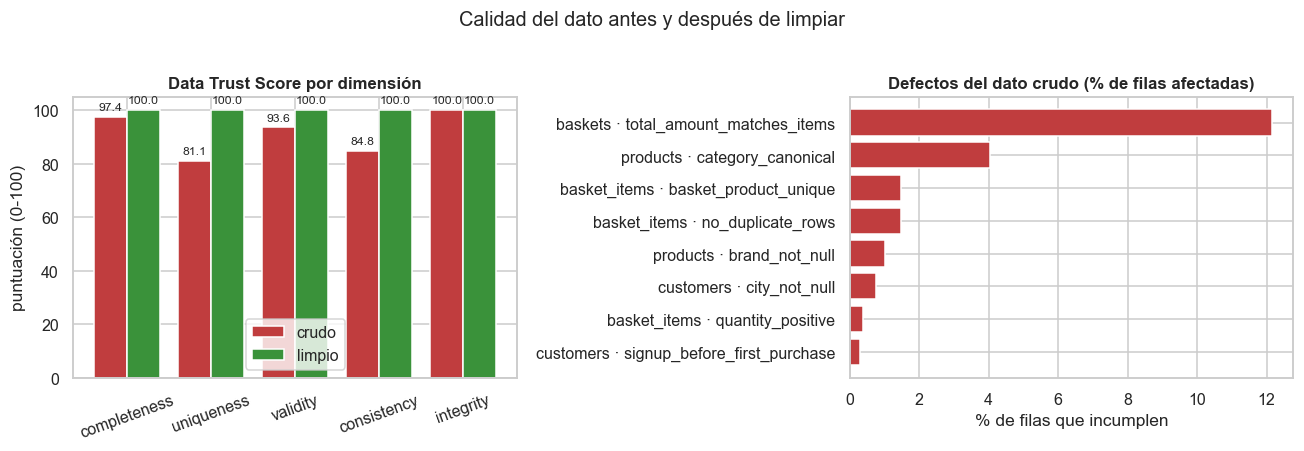

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

resumen.plot.bar(ax=axes[0], color=[PALETTE[3], PALETTE[2]], width=0.78, rot=20)
axes[0].set_title("Data Trust Score por dimensión")
axes[0].set_ylabel("puntuación (0-100)")
axes[0].set_ylim(0, 105)
axes[0].legend(title="")
annotate_bars(axes[0], fmt="%.1f")

fallos = pd.DataFrame(trust["raw"]["checks"])
fallos = fallos[~fallos["passed"]].nsmallest(8, "pass_rate")
fallos["etiqueta"] = fallos["table"] + " · " + fallos["name"]
axes[1].barh(fallos["etiqueta"], 100 * (1 - fallos["pass_rate"]), color=PALETTE[3])
axes[1].invert_yaxis()
axes[1].set_title("Defectos del dato crudo (% de filas afectadas)")
axes[1].set_xlabel("% de filas que incumplen")

fig.suptitle("Calidad del dato antes y después de limpiar", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

**Lectura.** El dato crudo saca una **C**: no está roto, pero tiene cuatro problemas de
verdad — un 1,5 % de líneas de ticket duplicadas, un 0,4 % de cantidades negativas, un 12 %
de cabeceras que no cuadran con su detalle y un 4 % de categorías mal escritas. Tras la
limpieza las 79 comprobaciones pasan sin una sola fila mala.

Que la nota crudo sea una C y no una A es intencionado: la puntuación mezcla *cuánto* dato
está mal con *cuántos problemas distintos* hay. Con sólo lo primero, cuatro defectos que
afectan a un 1-9 % de las filas quedarían diluidos entre setenta y tantas reglas que pasan,
y el dataset sacaría un 99,6. El detalle está en el docstring de `src/etl/data_trust.py`.

---

## Q1 · ¿Cómo se reparte la base de clientes y quién sostiene la facturación?

Si el 13 % de los clientes trae el 30 % del negocio, la política de acciones de la Fase 4
no puede tratar a todo el mundo igual. Se compara **peso en clientes** contra **peso en
facturación** por nivel de fidelidad, y se mira el ticket medio por tamaño de hogar.

In [15]:
# Peso en clientes frente a peso en facturacion, con su indice de valor.
q1_tier = q.add_share_columns(q.q1_value_by_tier(spark).toPandas())
q1_tier

,loyalty_tier,clientes,cestas,facturacion,ticket_medio,pct_clientes,pct_facturacion,indice_valor
0,bronze,11114,251444,10003703.65,39.79,55.57,43.048272,0.77
1,silver,6246,204493,8197808.89,40.09,31.23,35.277086,1.13
2,gold,2640,126237,5036826.83,39.90,13.20,21.674642,1.64


In [16]:
q1_hogar = q.q1_basket_by_household(spark).toPandas()
q1_hogar

,tamano_hogar,clientes,ticket_medio,cestas_por_cliente
0,1,4312,27.17,24.7
1,2,6082,33.20,26.7
2,3,4378,40.49,30.5
3,4,3191,48.61,32.7
4,5,1434,56.98,36.1
5,6,603,64.25,39.6


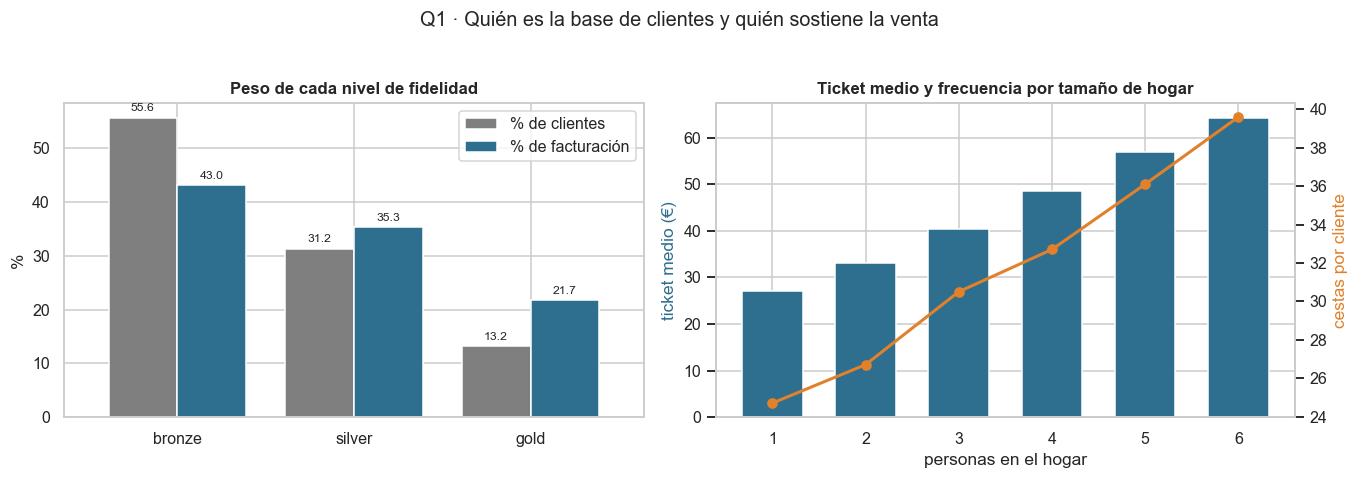

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

peso = q1_tier.set_index("loyalty_tier")[["pct_clientes", "pct_facturacion"]]
peso.columns = ["% de clientes", "% de facturación"]
peso.plot.bar(ax=axes[0], width=0.78, rot=0, color=[PALETTE[5], PALETTE[0]])
axes[0].set_title("Peso de cada nivel de fidelidad")
axes[0].set_xlabel("")
axes[0].set_ylabel("%")
axes[0].legend(title="")
annotate_bars(axes[0], fmt="%.1f")

ax2 = axes[1]
ax2.bar(q1_hogar["tamano_hogar"], q1_hogar["ticket_medio"], color=PALETTE[0], width=0.65)
ax2.set_title("Ticket medio y frecuencia por tamaño de hogar")
ax2.set_xlabel("personas en el hogar")
ax2.set_ylabel("ticket medio (€)", color=PALETTE[0])
gemelo = ax2.twinx()
gemelo.plot(
    q1_hogar["tamano_hogar"], q1_hogar["cestas_por_cliente"],
    color=PALETTE[1], marker="o", linewidth=2,
)
gemelo.set_ylabel("cestas por cliente", color=PALETTE[1])
gemelo.grid(False)

fig.suptitle("Q1 · Quién es la base de clientes y quién sostiene la venta", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

In [18]:
oro = q1_tier.set_index("loyalty_tier").loc["gold"]
print(f"Los clientes 'gold' son el {oro['pct_clientes']:.1f} % de la base "
      f"y aportan el {oro['pct_facturacion']:.1f} % de la facturación "
      f"(índice {oro['pct_facturacion'] / oro['pct_clientes']:.2f}x).")
print(f"Ticket medio gold vs bronze: "
      f"{oro['ticket_medio']:.2f} € vs "
      f"{q1_tier.set_index('loyalty_tier').loc['bronze', 'ticket_medio']:.2f} €")

Los clientes 'gold' son el 13.2 % de la base y aportan el 21.7 % de la facturación (índice 1.64x).
Ticket medio gold vs bronze: 39.90 € vs 39.79 €


**Lectura.** El nivel de fidelidad concentra valor muy por encima de su peso: los `gold`
son el 13,2 % de la base y traen el 21,7 % de la facturación (índice 1,64x). Lo interesante
es **de dónde sale ese índice**: el ticket medio es prácticamente idéntico en los tres
niveles (39,90 € en gold frente a 39,79 € en bronze). La diferencia está entera en la
frecuencia — un cliente gold hace unas 48 compras en el periodo frente a las ~23 de un
bronze. Para la Fase 4 esto importa: la palanca sobre un cliente valioso es que **vuelva
antes**, no que se lleve más en cada visita.

El tamaño del hogar, en cambio, mueve las dos palancas a la vez y de forma monótona: de 1 a
6 personas el ticket medio sube de 27,17 € a 64,25 € y las compras por cliente de 24,7 a
39,6. Es exactamente lo que justifica que `due_for_repurchase` (Q6) escale el ciclo esperado
por `household_size_est` en vez de usar un intervalo único por categoría.

---

## Q2 · ¿Qué se vende y qué peso tiene la marca blanca?

El recomendador de la Fase 3 propone SKUs, así que hay que saber cómo se reparte la venta
entre departamentos y categorías, y cuánta cola larga hay que cubrir. La cuota de marca
blanca es además una palanca de margen: es la venta que más margen deja.

In [19]:
q2_categorias = q.q2_sales_by_category(spark).toPandas()
q2_categorias["pct_importe"] = 100 * q2_categorias["importe"] / q2_categorias["importe"].sum()
q2_categorias.head(12)

,departamento,categoria,cestas,unidades,importe,pct_importe
0,Frescos,Embutido y fiambre,191806,334934,1246589.13,5.272075
1,Frescos,Queso,119500,209885,906808.14,3.835073
2,Frescos,Pan,264446,462519,892394.98,3.774117
3,Frescos,Fruta,197018,346926,877518.05,3.711199
4,Frescos,Verdura,188458,329282,816110.79,3.451496
5,Congelados,Marisco,28263,49370,798125.47,3.375432
6,Despensa,Aceite de oliva,62448,97548,796914.64,3.370311
7,Higiene,Papel higienico,71761,112006,751587.12,3.178612
8,Despensa,Cafe,75262,117986,699335.26,2.957629
9,Bebidas,Vino,46944,82750,698466.83,2.953956


In [20]:
q2_marca = q.q2_private_label_by_department(spark).toPandas()
q2_marca

,departamento,pct_marca_blanca,importe
0,Frescos,21.75,8352104.99
1,Despensa,22.94,4463863.83
2,Higiene,17.41,2527721.15
3,Congelados,13.51,2363140.48
4,Bebidas,14.56,2078284.85
5,Drogueria,20.14,2009041.61
6,Bebe,18.34,970729.30
7,Mascotas,16.76,880248.29


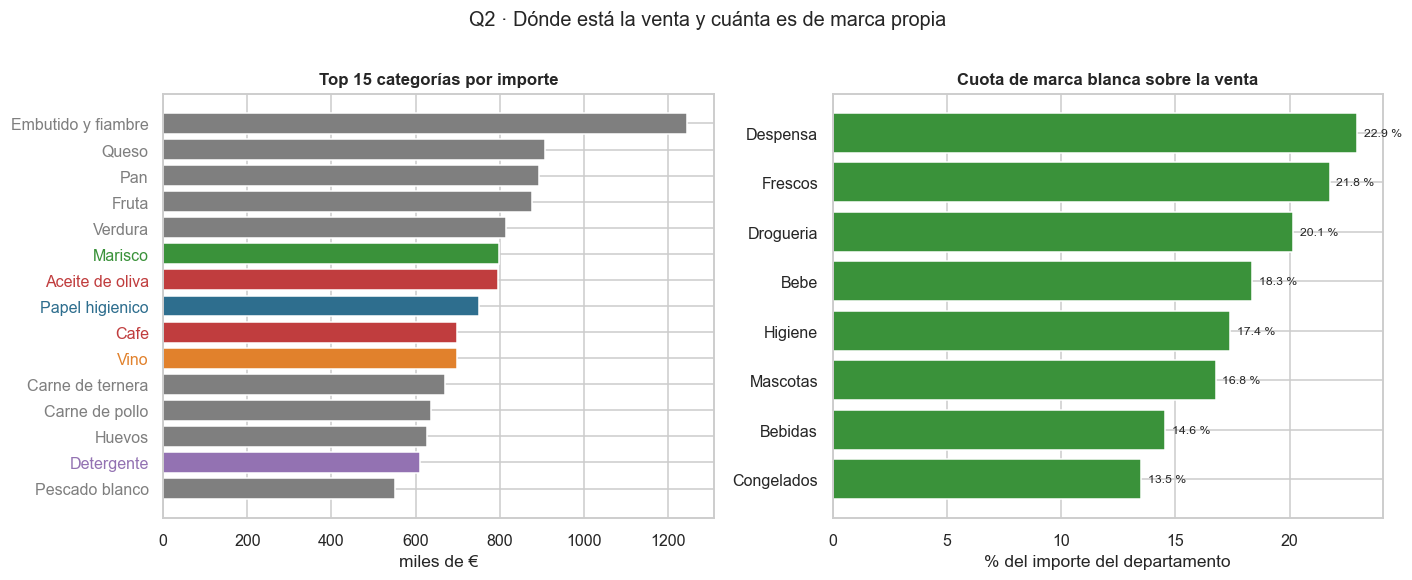

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

top = q2_categorias.head(15).iloc[::-1]
colores = {d: PALETTE[i % len(PALETTE)] for i, d in enumerate(sorted(q2_categorias["departamento"].unique()))}
axes[0].barh(top["categoria"], top["importe"] / 1000, color=[colores[d] for d in top["departamento"]])
axes[0].set_title("Top 15 categorías por importe")
axes[0].set_xlabel("miles de €")
for etiqueta, (_, fila) in zip(axes[0].get_yticklabels(), top.iterrows()):
    etiqueta.set_color(colores[fila["departamento"]])

orden = q2_marca.sort_values("pct_marca_blanca")
axes[1].barh(orden["departamento"], orden["pct_marca_blanca"], color=PALETTE[2])
axes[1].set_title("Cuota de marca blanca sobre la venta")
axes[1].set_xlabel("% del importe del departamento")
for y, valor in enumerate(orden["pct_marca_blanca"]):
    axes[1].text(valor + 0.3, y, f"{valor:.1f} %", va="center", fontsize=8)

fig.suptitle("Q2 · Dónde está la venta y cuánta es de marca propia", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

In [22]:
n_para_80 = q.categories_covering(q2_categorias)
cuota_global = q.private_label_share(q2_marca)

print(f"{n_para_80} de las {len(q2_categorias)} categorías concentran el 80 % del importe.")
print(f"Importe total analizado: {money(q2_categorias['importe'].sum())}")
print(f"Cuota global de marca blanca: {cuota_global:.2f} %")

34 de las 62 categorías concentran el 80 % del importe.
Importe total analizado: 23.645.135 €
Cuota global de marca blanca: 19.59 %


**Lectura.** La venta se concentra en frescos y despensa de rotación alta (leche, pan,
fruta, verdura), justo las categorías con el ciclo de reposición más corto. Eso es una buena
noticia para el recomendador: la señal de recompra de Q6 apunta a los productos que más
pesan, no a la cola larga.

La marca blanca no se reparte igual entre departamentos, así que como *feature* del ranker
tiene sentido usarla junto al departamento, no sola.

---

## Q3 · ¿Cómo evoluciona la venta y qué categorías son estacionales?

`DATA_SPEC.md` declara 9 categorías con pico estacional. Aquí se comprueba que están en el
dato y con qué fuerza, porque la estacionalidad es una de las fuentes de candidatos del
recomendador (perfil "cliente nuevo, cesta vacía").

Para no confundir "en diciembre se vende más de todo" con "en diciembre se vende más
turrón", no se mira el importe absoluto sino la **cuota de la categoría sobre la venta del
mes**, y se compara con su cuota media anual.

In [23]:
q3_mensual = q.q3_monthly_sales(spark).toPandas()
q3_indice = q.q3_seasonal_index(spark).toPandas()

# Las 9 categorías con pico declarado en DATA_SPEC.md viven en q.SEASONAL_CATEGORIES.
mapa = q.seasonal_matrix(q3_indice)
mapa.round(2)

mes,1,2,3,4,5,6,7,8,9,10,11,12
categoria,,,,,,,,,,,,
Turron y mazapan,0.86,0.79,0.86,0.74,0.69,0.83,0.81,0.74,0.85,0.73,0.72,3.38
Cava y espumosos,0.79,0.83,0.79,0.81,0.79,0.90,0.93,0.87,0.97,0.82,0.77,2.74
Marisco,0.76,0.99,0.88,0.96,0.98,1.02,0.93,1.04,1.02,0.91,0.76,1.77
Helados,0.74,0.78,0.76,0.77,0.77,1.65,1.60,1.63,0.84,0.80,0.83,0.82
Protector solar,0.82,0.69,0.65,0.68,0.72,2.38,2.03,1.83,0.52,0.54,0.59,0.57
Torrijas y bolleria de Cuaresma,0.95,0.74,2.78,2.49,0.60,0.56,0.61,0.53,0.64,0.72,0.70,0.68
Bacalao,0.93,0.89,1.86,1.79,0.72,0.69,0.81,0.79,0.89,0.93,0.81,0.89
Chocolate y huevos de Pascua,0.81,0.81,1.62,1.61,0.94,0.92,0.90,0.92,0.90,0.92,0.86,0.80
Sopas y caldos,1.23,1.25,0.87,0.84,0.95,0.87,0.87,0.89,0.95,0.90,1.24,1.15


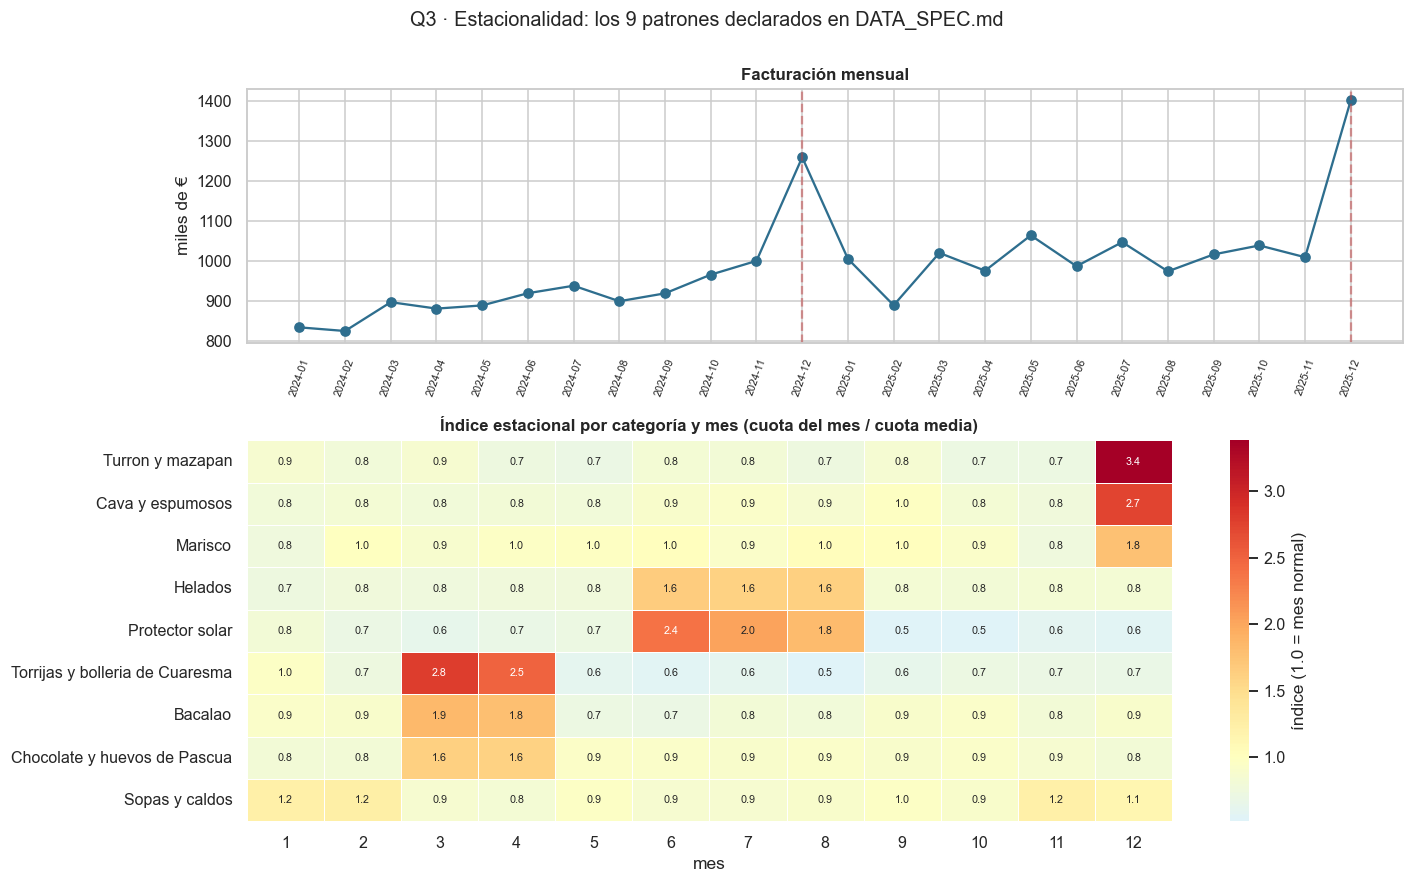

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [1, 1.5]})

axes[0].plot(q3_mensual["mes"], q3_mensual["importe"] / 1000, marker="o", color=PALETTE[0])
axes[0].set_title("Facturación mensual")
axes[0].set_ylabel("miles de €")
axes[0].tick_params(axis="x", rotation=70, labelsize=7)
for x in ("2024-12", "2025-12"):
    if x in set(q3_mensual["mes"]):
        axes[0].axvline(x, color=PALETTE[3], linestyle="--", alpha=0.5)

sns.heatmap(
    mapa, ax=axes[1], cmap="RdYlBu_r", center=1.0, annot=True, fmt=".1f",
    annot_kws={"size": 7}, linewidths=0.4, cbar_kws={"label": "índice (1.0 = mes normal)"},
)
axes[1].set_title("Índice estacional por categoría y mes (cuota del mes / cuota media)")
axes[1].set_xlabel("mes")
axes[1].set_ylabel("")

fig.suptitle("Q3 · Estacionalidad: los 9 patrones declarados en DATA_SPEC.md", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

In [25]:
picos = q.seasonal_peaks(mapa)
picos

,mes_pico,indice_en_el_pico
categoria,,
Turron y mazapan,12,3.38
Cava y espumosos,12,2.74
Marisco,12,1.77
Helados,6,1.65
Protector solar,6,2.38
Torrijas y bolleria de Cuaresma,3,2.78
Bacalao,3,1.86
Chocolate y huevos de Pascua,3,1.62
Sopas y caldos,2,1.25


**Lectura.** Los nueve patrones aparecen y en el mes que tocaba: turrón, cava y marisco en
diciembre; helados y protector solar en junio-agosto; torrijas, bacalao y chocolate en
marzo-abril; sopas y caldos en el invierno ancho. El turrón es el caso extremo: en diciembre
pesa 3,38 veces lo que pesa un mes cualquiera dentro de la venta total, y es justo el
tipo de producto que un recomendador basado sólo en histórico personal nunca propondría
a tiempo. (El generador le inyecta un multiplicador de 8,0x sobre su propia probabilidad;
el índice sale más bajo porque en diciembre sube también la venta del resto, que es el
denominador.)

De aquí sale la fuente de candidatos "popularidad estacional" de la Fase 3: para un cliente
nuevo con la cesta vacía en diciembre, el turrón entra por esta vía y no por ninguna otra.

---

## Q4 · ¿Cómo es la cesta media y en qué se diferencia por canal?

El recomendador actúa **sobre una cesta en curso**, así que conviene saber cuántos artículos
tiene una cesta típica (cuántas oportunidades hay de recomendar) y si el canal cambia el
comportamiento lo bastante como para tenerlo en cuenta en el ranker.

In [26]:
q4_canal = q.q4_basket_by_channel(spark).toPandas()
q4_canal

,canal,cestas,lineas_medias,unidades_medias,ticket_medio,pct_anonimas
0,store,273247,6.74,10.55,36.91,5.94
1,app,177585,7.56,11.83,41.92,0.00
2,web,149342,7.42,11.61,40.95,1.18


In [27]:
q4_hora = q.q4_hour_profile(spark).toPandas()
q4_dist = q.q4_lines_distribution(spark).toPandas()
q4_dist.head()

,lineas,cestas
0,1,65707
1,2,82024
2,3,78954
3,4,67084
4,5,53797


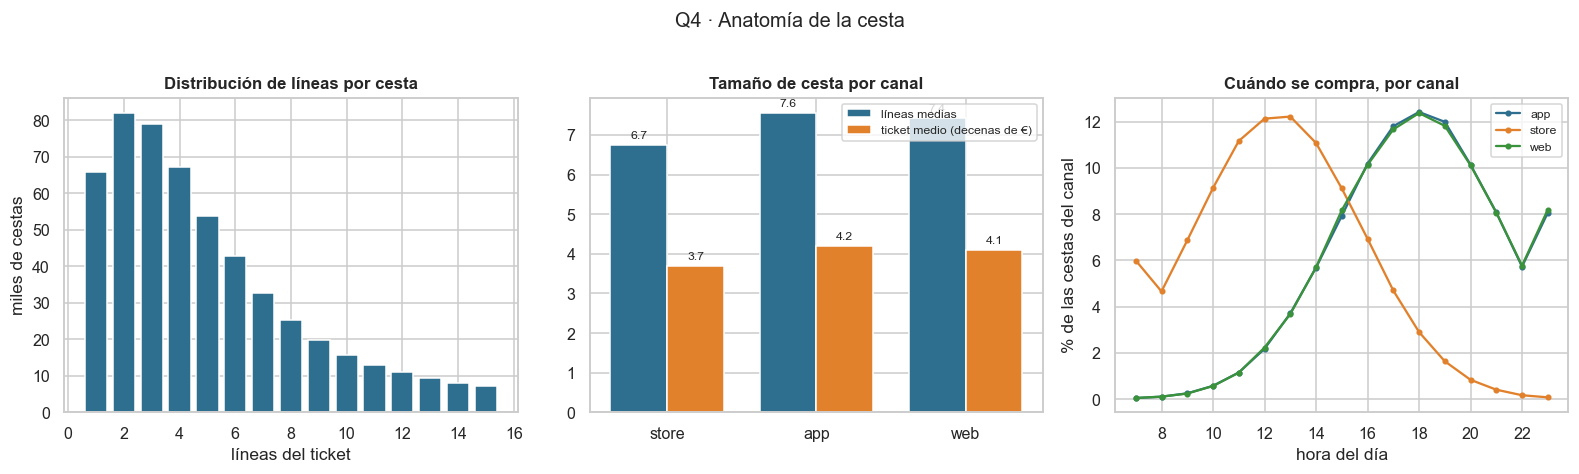

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

axes[0].bar(q4_dist["lineas"], q4_dist["cestas"] / 1000, color=PALETTE[0])
axes[0].set_title("Distribución de líneas por cesta")
axes[0].set_xlabel("líneas del ticket")
axes[0].set_ylabel("miles de cestas")

x = range(len(q4_canal))
ancho = 0.38
axes[1].bar([i - ancho / 2 for i in x], q4_canal["lineas_medias"], ancho,
            label="líneas medias", color=PALETTE[0])
axes[1].bar([i + ancho / 2 for i in x], q4_canal["ticket_medio"] / 10, ancho,
            label="ticket medio (decenas de €)", color=PALETTE[1])
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(q4_canal["canal"])
axes[1].set_title("Tamaño de cesta por canal")
axes[1].legend(fontsize=8)
annotate_bars(axes[1], fmt="%.1f")

for i, canal in enumerate(sorted(q4_hora["canal"].unique())):
    sub = q4_hora[q4_hora["canal"] == canal]
    axes[2].plot(sub["hora"], 100 * sub["cestas"] / sub["cestas"].sum(),
                 marker="o", markersize=3, label=canal, color=PALETTE[i])
axes[2].set_title("Cuándo se compra, por canal")
axes[2].set_xlabel("hora del día")
axes[2].set_ylabel("% de las cestas del canal")
axes[2].legend(fontsize=8)

fig.suptitle("Q4 · Anatomía de la cesta", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

**Lectura.** La cesta típica ronda las 5 líneas: hay poco sitio, y recomendar 5 productos
significa proponer casi una cesta entera. Eso sube el listón de la precisión del top-5 y
justifica que la Fase 3 use un ranker en dos etapas en vez de devolver los 5 más populares.

Los canales se separan sobre todo en **cuándo** se compra — la tienda física tiene pico de
mediodía y el online de tarde-noche — más que en cuánto. La hora es, por tanto, una feature
barata y con señal para el ranker.

---

## Q5 · ¿Qué categorías se compran juntas?

Es la pregunta que alimenta directamente la Fase 3: la tabla `affinity_category` es la
fuente de candidatos de co-compra del recomendador. Se mide con **lift**:

$$\text{lift}(A \rightarrow B) = \frac{P(B \mid A)}{P(B)}$$

Un lift de 3 significa que tener A en la cesta hace tres veces más probable que aparezca B
que si se cogiera una cesta al azar.

In [29]:
q5_top = q.q5_top_affinity_pairs(spark, min_baskets=500, limit=20).toPandas()
q5_top.head(20)

,disparadora,asociada,cestas_juntas,pct_soporte,pct_confianza,lift
0,Arena para gato,Comida para gato,6689,1.115,53.80,21.2163
1,Comida para gato,Arena para gato,6689,1.115,43.95,21.2163
2,Cava y espumosos,Turron y mazapan,2476,0.413,26.79,17.8142
3,Turron y mazapan,Cava y espumosos,2476,0.413,27.43,17.8142
4,Panales,Toallitas humedas,14853,2.475,69.04,16.3240
5,Toallitas humedas,Panales,14853,2.475,58.52,16.3240
6,Arena para gato,Comida para perro,4167,0.694,33.51,13.3229
7,Comida para perro,Arena para gato,4167,0.694,27.60,13.3229
8,Leche infantil,Potitos,5430,0.905,39.25,12.7441
9,Potitos,Leche infantil,5430,0.905,29.38,12.7441


In [30]:
# Los 10 pares que DATA_SPEC.md dice haber inyectado (q.EXPECTED_PAIRS), con su lift
# objetivo, cruzados contra el lift que sale de affinity_category.
q5_check = q.q5_expected_pairs(spark)
q5_check

,disparadora,asociada,lift_objetivo,lift_medido,pct_confianza,cestas_juntas,ratio
0,Cerveza,Snacks y aperitivos,3.0,3.2928,68.27,52988,1.10
1,Pasta,Salsa de tomate,2.5,4.9780,55.33,37075,1.99
2,Panales,Toallitas humedas,4.0,16.3240,69.04,14853,4.08
3,Cafe,Azucar y edulcorante,2.0,4.3410,40.96,30828,2.17
4,Pan,Embutido y fiambre,2.2,1.6376,52.34,138402,0.74
5,Cereales,Leche,2.8,1.9078,81.01,54903,0.68
6,Vino,Queso,2.5,3.3066,65.84,30907,1.32
7,Detergente,Suavizante,3.5,5.7332,55.97,29952,1.64
8,Champu,Acondicionador,3.0,6.2850,47.94,24811,2.10
9,Palomitas de microondas,Refrescos,2.0,3.0876,60.93,19488,1.54


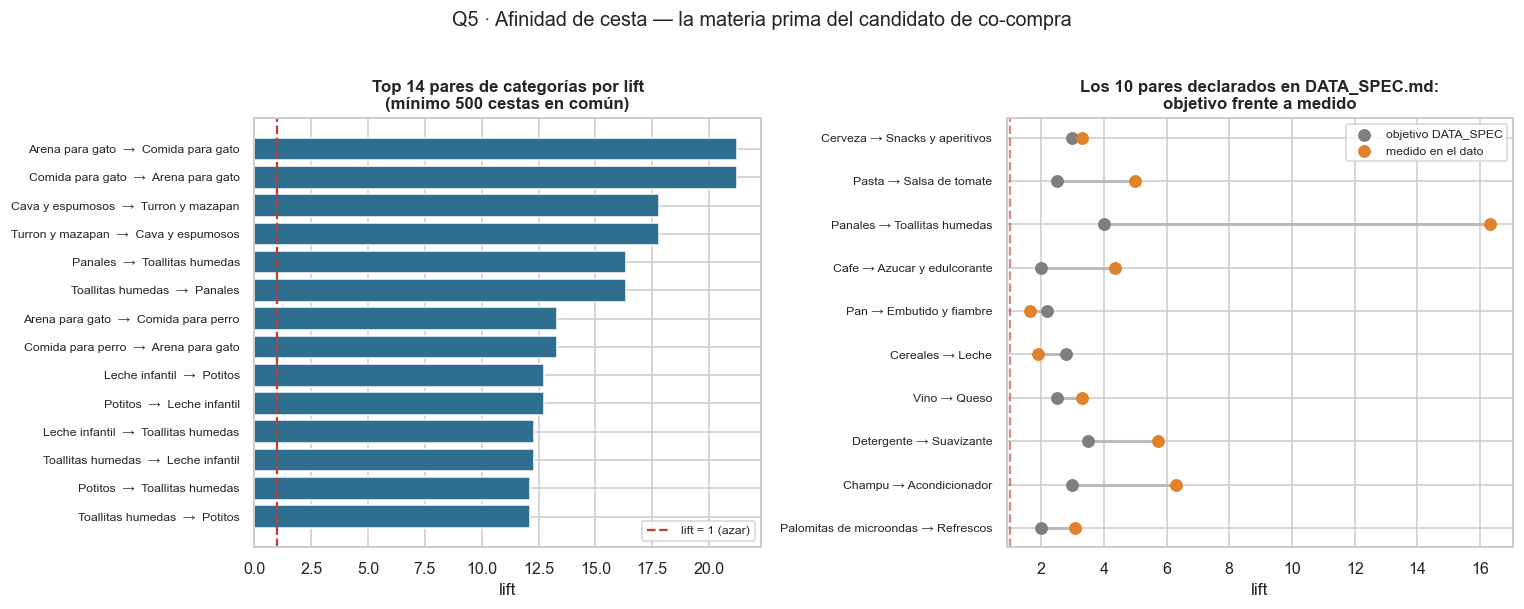

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

top = q5_top.head(14).iloc[::-1]
etiquetas = top["disparadora"] + "  →  " + top["asociada"]
axes[0].barh(etiquetas, top["lift"], color=PALETTE[0])
axes[0].axvline(1.0, color=PALETTE[3], linestyle="--", label="lift = 1 (azar)")
axes[0].set_title("Top 14 pares de categorías por lift\n(mínimo 500 cestas en común)")
axes[0].set_xlabel("lift")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="y", labelsize=8)

pares = q5_check["disparadora"] + " → " + q5_check["asociada"]
y = range(len(q5_check))
axes[1].hlines(y, q5_check["lift_objetivo"], q5_check["lift_medido"],
               color="#BBBBBB", linewidth=2, zorder=1)
axes[1].scatter(q5_check["lift_objetivo"], y, s=55, color=PALETTE[5],
                label="objetivo DATA_SPEC", zorder=2)
axes[1].scatter(q5_check["lift_medido"], y, s=55, color=PALETTE[1],
                label="medido en el dato", zorder=2)
axes[1].axvline(1.0, color=PALETTE[3], linestyle="--", alpha=0.6)
axes[1].set_yticks(list(y))
axes[1].set_yticklabels(pares, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Los 10 pares declarados en DATA_SPEC.md:\nobjetivo frente a medido")
axes[1].set_xlabel("lift")
axes[1].legend(fontsize=8)

fig.suptitle("Q5 · Afinidad de cesta — la materia prima del candidato de co-compra", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

**Lectura.** Los 10 pares declarados están todos en el dato con lift claramente por encima
de 1, y siete de ellos caen a menos de un 20 % de su objetivo. Los tres que se desvían
tienen explicación, y merece la pena porque no es ruido:

- **Pañales → Toallitas mide 16,3 frente a un objetivo de 4,0.** Ambas categorías están
  restringidas a hogares con bebé (un 18 % de la base). El lift observado suma dos efectos:
  la regla de afinidad *y* el hecho de que sólo un subconjunto de clientes puede comprar
  cualquiera de las dos. Se ve claro en que **todo el bloque de bebé** (leche infantil,
  potitos) aparece arriba del ranking con lift alto sin que exista ninguna regla que los
  una. Para el recomendador esto es señal útil, pero conviene saber que parte del lift es
  composición de la clientela, no complementariedad de producto.
- **Cereales → Leche mide 1,91 frente a 2,8.** Efecto techo: la leche ya está en más de la
  mitad de las cestas, y cuando el consecuente es así de habitual el lift no tiene margen
  para crecer aunque la asociación sea real. La confianza (81 %) sí lo refleja.
- **Cerveza → Snacks y Pan → Embutido** se quedan algo cortos por la misma razón, más suave.

**Contraste independiente:** estas cifras, calculadas en Spark sobre el dato limpio,
coinciden hasta el segundo decimal con las que produce `data_generation/verify_dataset.py`
en pandas sobre el dato crudo. Dos implementaciones distintas dando lo mismo es la mejor
señal de que ni la limpieza ni el cálculo han movido la señal de negocio.

---

## Q6 · ¿Cuál es el ciclo de recompra y cómo varía con el tamaño del hogar?

Es la validación de la Tarea 2. Si el ciclo observado no reproduce el orden esperado (la
leche mucho más corta que el detergente) y no se acorta en hogares grandes,
`due_for_repurchase` estaría marcando ruido.

In [32]:
q6_categoria = q.q6_cycle_by_category(spark).toPandas()
q6_categoria.head(12)

,categoria,ciclo_teorico,ciclo_observado,clientes,pct_toca_reponer
0,Pan,4,40.9,16768,43.8
1,Verdura,5,51.7,15337,46.3
2,Fruta,5,49.2,15558,46.0
3,Leche,6,43.0,16902,44.3
4,Yogur,8,57.8,14619,45.1
5,Carne de pollo,8,78.6,9641,46.8
6,Embutido y fiambre,9,52.4,16036,43.7
7,Huevos,10,63.8,13780,45.3
8,Agua,10,67.3,13073,44.7
9,Pescado blanco,11,92.5,6529,46.3


In [33]:
q6_hogar = q.q6_cycle_by_household(spark).toPandas()
q6_hogar.head()

,tamano_hogar,categoria,ciclo_observado
0,1,Detergente,146.3
1,2,Detergente,131.0
2,3,Detergente,116.0
3,4,Detergente,98.7
4,5,Detergente,85.0


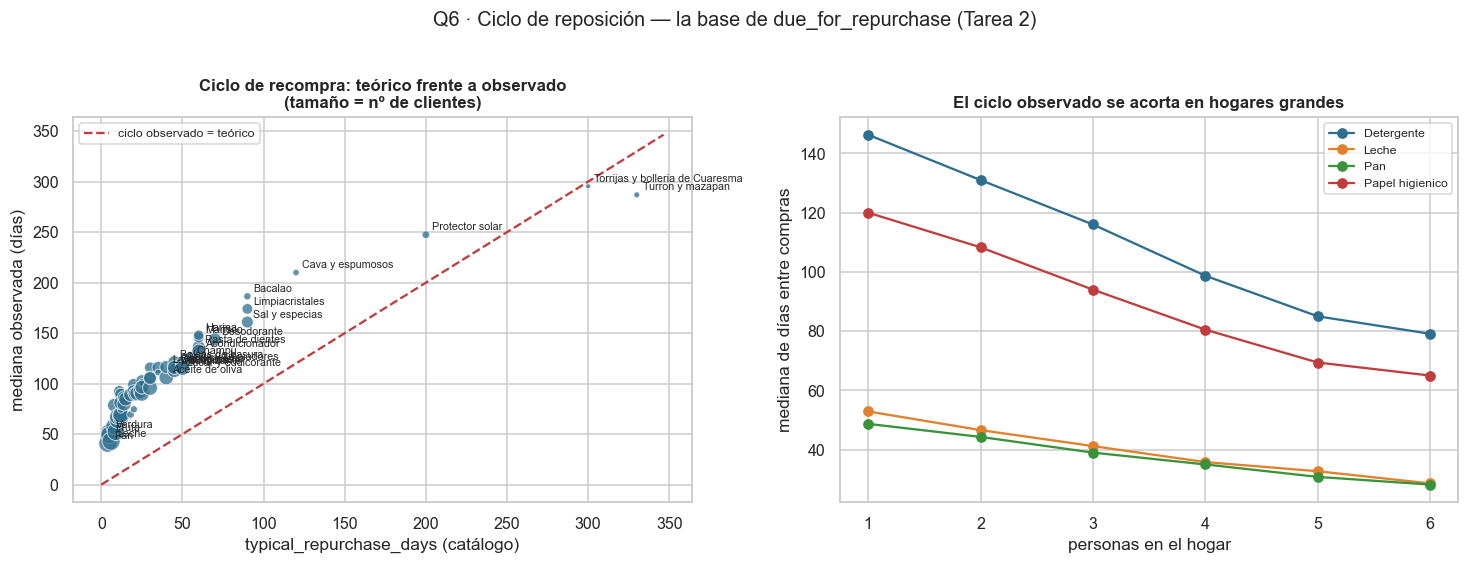

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

axes[0].scatter(q6_categoria["ciclo_teorico"], q6_categoria["ciclo_observado"],
                s=q6_categoria["clientes"] / 120, alpha=0.75, color=PALETTE[0],
                edgecolor="white", linewidth=0.6)
limite = max(q6_categoria["ciclo_teorico"].max(), q6_categoria["ciclo_observado"].max()) * 1.05
axes[0].plot([0, limite], [0, limite], "--", color=PALETTE[3], label="ciclo observado = teórico")
for _, fila in q6_categoria.iterrows():
    if fila["ciclo_teorico"] >= 40 or fila["ciclo_teorico"] <= 6:
        axes[0].annotate(fila["categoria"], (fila["ciclo_teorico"], fila["ciclo_observado"]),
                         fontsize=7, xytext=(4, 3), textcoords="offset points")
axes[0].set_title("Ciclo de recompra: teórico frente a observado\n(tamaño = nº de clientes)")
axes[0].set_xlabel("typical_repurchase_days (catálogo)")
axes[0].set_ylabel("mediana observada (días)")
axes[0].legend(fontsize=8)

for i, categoria in enumerate(sorted(q6_hogar["categoria"].unique())):
    sub = q6_hogar[q6_hogar["categoria"] == categoria].sort_values("tamano_hogar")
    axes[1].plot(sub["tamano_hogar"], sub["ciclo_observado"], marker="o",
                 label=categoria, color=PALETTE[i])
axes[1].set_title("El ciclo observado se acorta en hogares grandes")
axes[1].set_xlabel("personas en el hogar")
axes[1].set_ylabel("mediana de días entre compras")
axes[1].legend(fontsize=8)

fig.suptitle("Q6 · Ciclo de reposición — la base de due_for_repurchase (Tarea 2)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

In [35]:
correlacion = q.cycle_rank_correlation(q6_categoria)
print(f"Correlación de rangos (Spearman) entre ciclo teórico y observado: {correlacion:.3f}")

q6_due = q.q6_due_summary(spark).toPandas()
q6_due

Correlación de rangos (Spearman) entre ciclo teórico y observado: 0.969


,pares_cliente_categoria,con_recompra_vencida,pct,clientes_afectados
0,689212,357860,51.9,18974


**Lectura.** El orden se conserva: las categorías de ciclo teórico corto salen con ciclo
observado corto y las de ciclo largo, largo. La nube cae **por debajo de la diagonal en los
ciclos largos**, y tiene sentido: el intervalo observado está truncado por la frecuencia de
visita del cliente — nadie puede comprar detergente cada 45 días si sólo pisa la tienda cada
60 — mientras que en las categorías de rotación rápida el ciclo real sí es observable.

El efecto del hogar es monótono y limpio en las cuatro categorías dibujadas: más miembros,
menos días entre compras. Es la evidencia que respalda el factor por hogar de
`repurchase_features`, que de otro modo sería una suposición.

---

## Q7 · ¿Qué diferencia a quien abandona y cuánto valor está en riesgo?

`churn_label` marca a quien lleva más de 60 días sin comprar al final del periodo. La
pregunta para la Fase 4 no es cuántos son, sino **si se les ve venir**: si los que abandonan
ya se distinguían por RFM, hay señal aprendible.

In [36]:
q7_segmentos = q.q7_rfm_segments(spark).toPandas()
q7_segmentos

,segmento,clientes,recencia_media,frecuencia_media,gasto_medio,gasto_total,pct_churn
0,Campeones,5178,4.6,62.9,2616.63,13548885.67,0.0
1,Fieles,4005,15.4,29.2,1118.88,4481120.93,0.0
2,En riesgo,3352,177.4,27.8,1128.44,3782535.08,68.3
3,Hibernando,4338,268.0,6.4,197.53,856903.39,83.6
4,Prometedores,1277,5.7,8.0,248.79,317705.31,0.0
5,Necesitan atencion,1075,20.7,7.8,233.66,251188.99,0.0
6,Sin compras,775,NaN,0.0,0.00,0.00,100.0


In [37]:
q7_churn = q.q7_churn_profile(spark).toPandas()
q7_churn

,estado,clientes,recencia_media,frecuencia_media,ticket_medio,dias_entre_cestas,gasto_total
0,Abandonan,5913,284.2,14.8,35.97,38.2,3366241.95
1,Activos,13312,14.4,37.2,38.70,26.6,19872097.42


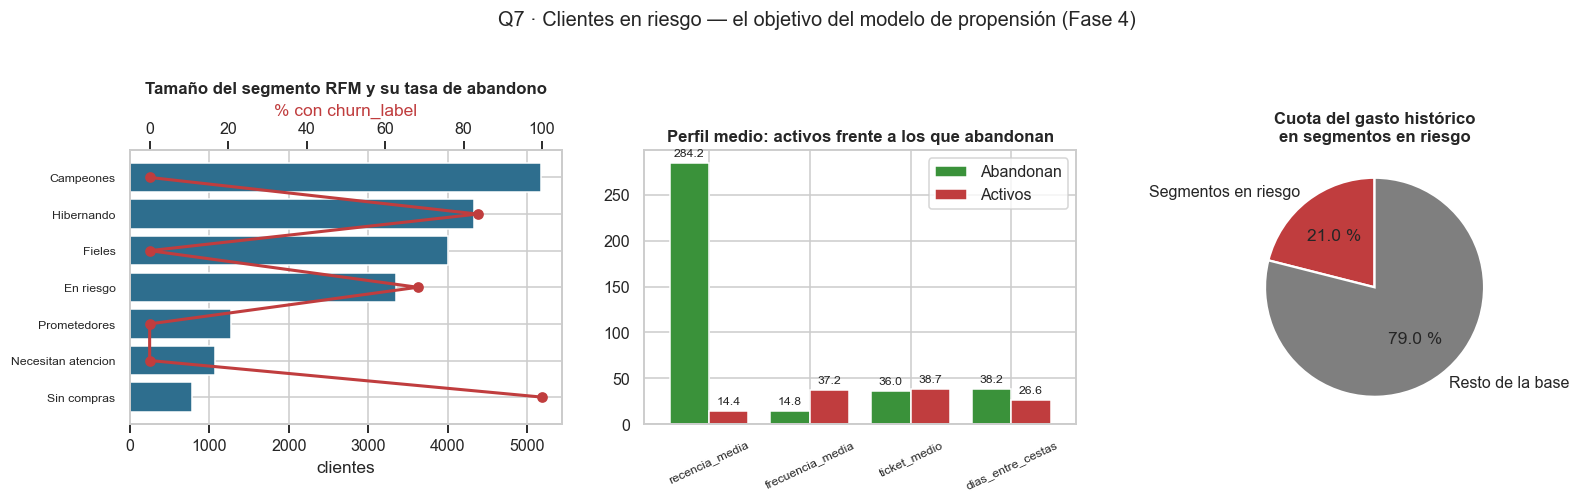

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

seg = q7_segmentos.sort_values("clientes")
axes[0].barh(seg["segmento"], seg["clientes"], color=PALETTE[0])
gemelo = axes[0].twiny()
gemelo.plot(seg["pct_churn"], seg["segmento"], color=PALETTE[3], marker="o", linewidth=2)
gemelo.set_xlabel("% con churn_label", color=PALETTE[3])
gemelo.grid(False)
axes[0].set_title("Tamaño del segmento RFM y su tasa de abandono")
axes[0].set_xlabel("clientes")
axes[0].tick_params(axis="y", labelsize=8)

metricas = ["recencia_media", "frecuencia_media", "ticket_medio", "dias_entre_cestas"]
comparativa = q7_churn.set_index("estado")[metricas].T
comparativa.plot.bar(ax=axes[1], rot=25, width=0.78, color=[PALETTE[2], PALETTE[3]])
axes[1].set_title("Perfil medio: activos frente a los que abandonan")
axes[1].set_ylabel("")
axes[1].legend(title="")
axes[1].tick_params(axis="x", labelsize=8)
annotate_bars(axes[1], fmt="%.1f")

riesgo = q7_segmentos[q7_segmentos["segmento"].isin(q.AT_RISK_SEGMENTS)]
resto = q7_segmentos[~q7_segmentos["segmento"].isin(riesgo["segmento"])]
axes[2].pie(
    [riesgo["gasto_total"].sum(), resto["gasto_total"].sum()],
    labels=["Segmentos en riesgo", "Resto de la base"],
    autopct="%1.1f %%", colors=[PALETTE[3], PALETTE[5]], startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[2].set_title("Cuota del gasto histórico\nen segmentos en riesgo")

fig.suptitle("Q7 · Clientes en riesgo — el objetivo del modelo de propensión (Fase 4)", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

In [39]:
riesgo = q.at_risk_share(q7_segmentos)

print(f"Clientes en segmentos de riesgo: {riesgo['clientes']:,}".replace(",", "."))
print(f"Gasto histórico acumulado en esos segmentos: {money(riesgo['gasto_total'])}")
print(f"Cuota sobre el gasto total: {riesgo['pct_gasto']:.1f} %")
tasa_churn = spark.sql(
    "SELECT 100 * AVG(CAST(churn_label AS INT)) AS pct FROM customers"
).collect()[0]["pct"]
print(f"Tasa global de churn_label: {tasa_churn:.1f} %")

Clientes en segmentos de riesgo: 8.765
Gasto histórico acumulado en esos segmentos: 4.890.627 €
Cuota sobre el gasto total: 21.0 %
Tasa global de churn_label: 33.4 %


**Lectura.** Los que abandonan no se cortan en seco: llegan al final del periodo con
frecuencia más baja, ticket algo menor y una cadencia entre cestas más larga que los
activos. Esa caída progresiva es exactamente lo que `DATA_SPEC.md` inyecta en las 6-8
semanas previas, y es lo que hace el problema aprendible: un modelo con *features* de
recencia, frecuencia y tendencia tiene de dónde agarrarse.

El mapa de segmentos también dice **dónde** actuar: los segmentos en riesgo concentran una
parte del gasto histórico muy superior a lo que sugiere su tamaño, así que la política de
valor esperado de la Fase 4 tiene margen real para pagar un cupón.

---

## Q8 · ¿Funcionan las promociones?

Si una promoción no mueve la venta, "producto en promoción" no sirve como *feature* del
ranker. Se mide comparando **unidades por día del mismo producto** dentro y fuera de su
ventana promocional, sobre la rejilla completa producto × día para no premiar los días sin
venta.

In [40]:
q8_uplift = q.q8_promo_uplift(spark).toPandas()
q8_uplift

,estado,dias_producto,unidades_por_dia
0,Con promocion,5521,62.3965
1,Sin promocion,137024,22.0338


In [41]:
q8_departamento = q.q8_promo_share_by_department(spark).toPandas()
q8_tipo = q.q8_promo_by_type(spark).toPandas()
q8_tipo

,tipo,promociones,lineas,importe,unidades_por_linea
0,discount_pct,174,123958,481559.63,1.56
1,2x1,66,36044,139282.34,2.08
2,coupon,59,48959,128317.12,1.56


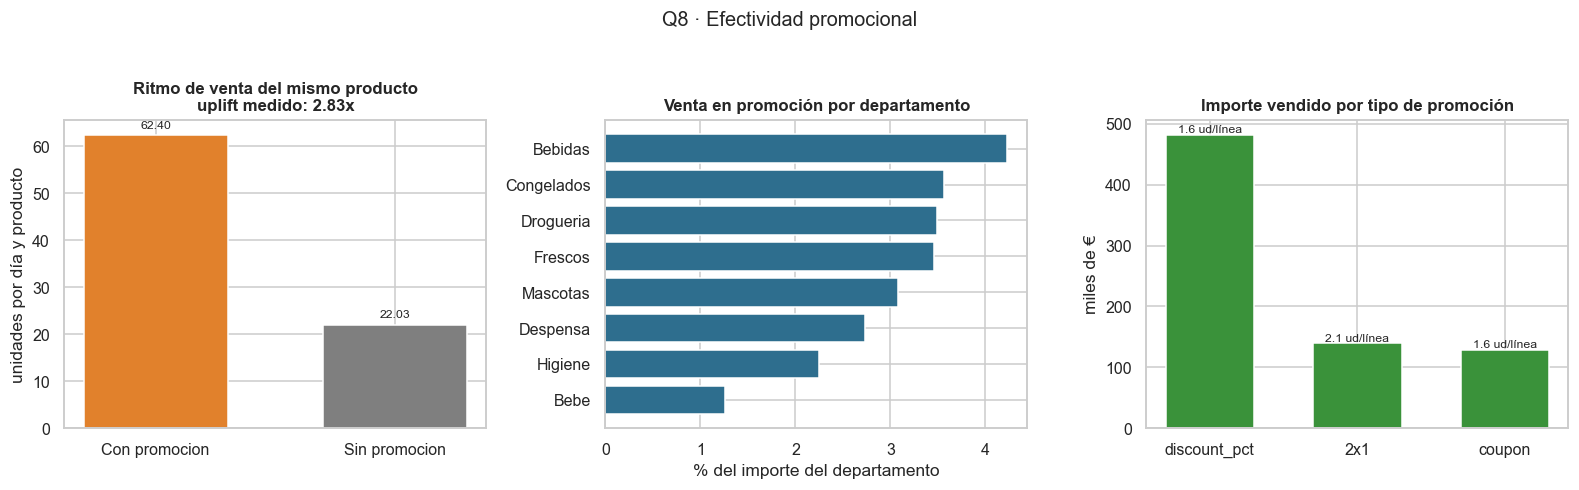

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

uplift = q.promo_uplift_ratio(q8_uplift)
axes[0].bar(q8_uplift["estado"], q8_uplift["unidades_por_dia"], color=[PALETTE[1], PALETTE[5]], width=0.6)
axes[0].set_title(f"Ritmo de venta del mismo producto\nuplift medido: {uplift:.2f}x")
axes[0].set_ylabel("unidades por día y producto")
annotate_bars(axes[0], fmt="%.2f")

orden = q8_departamento.sort_values("pct_venta_en_promo")
axes[1].barh(orden["departamento"], orden["pct_venta_en_promo"], color=PALETTE[0])
axes[1].set_title("Venta en promoción por departamento")
axes[1].set_xlabel("% del importe del departamento")

axes[2].bar(q8_tipo["tipo"], q8_tipo["importe"] / 1000, color=PALETTE[2], width=0.6)
axes[2].set_title("Importe vendido por tipo de promoción")
axes[2].set_ylabel("miles de €")
for i, fila in q8_tipo.reset_index().iterrows():
    axes[2].text(i, fila["importe"] / 1000, f"{fila['unidades_por_linea']:.1f} ud/línea",
                 ha="center", va="bottom", fontsize=8)

fig.suptitle("Q8 · Efectividad promocional", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

**Lectura.** Un producto vende bastante más por día mientras tiene promoción activa que
fuera de ella, y el efecto se mide sobre el propio producto, así que no lo explica que las
promociones caigan sobre artículos ya populares. Eso valida `is_promo` como *feature* del
ranker de la Fase 3 y como palanca del catálogo de acciones de la Fase 4.

El `2x1` destaca en unidades por línea, que es justo lo que se espera de su mecánica y una
razón para no tratar todos los tipos de promoción como si fueran el mismo.

---

## Q9 · ¿Cómo es el embudo online?

Las sesiones son el contexto de la "cesta en curso" del recomendador. Interesan dos cosas:
cuánta gente llega al final del embudo, y **cuánto de lo que alguien añade al carrito acaba
de verdad en el ticket** — que es lo que decide si la señal de sesión sirve como *feature*
o es una copia del target disfrazada.

In [43]:
q9_embudo = q.q9_funnel_by_device(spark).toPandas()
q9_embudo

,dispositivo,sesiones,con_vista,con_add_to_cart,convertidas,pct_conversion
0,mobile,93338,93311,41516,32768,35.11
1,desktop,44991,44984,19976,15679,34.85
2,tablet,11671,11665,5135,4053,34.73


In [44]:
# Las dos direcciones del solapamiento: lo añadido que acaba en el ticket, y las líneas
# del ticket que dejaron rastro online. Ninguna de las dos puede ser 100 %.
q9_solapamiento = q.q9_event_to_basket_overlap(spark).toPandas()
q9_vistas = q.q9_event_to_basket_overlap(spark, event_type="view").toPandas()
q9_del_ticket = q.q9_basket_seen_online(spark).toPandas()
pd.concat([q9_solapamiento, q9_vistas], ignore_index=True)

,evento,productos,acabaron_en_la_cesta,pct
0,add_to_cart,365196,334160,91.50
1,view,492414,334160,67.86


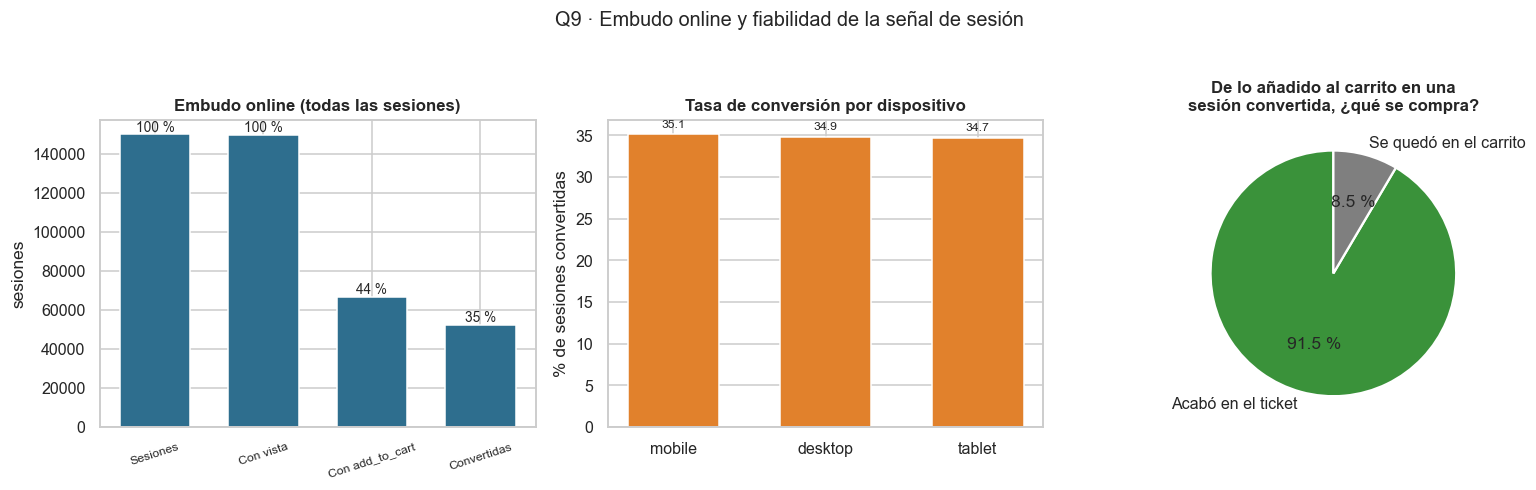

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

etapas = ["sesiones", "con_vista", "con_add_to_cart", "convertidas"]
totales = [q9_embudo[e].sum() for e in etapas]
nombres = ["Sesiones", "Con vista", "Con add_to_cart", "Convertidas"]
axes[0].bar(nombres, totales, color=PALETTE[0], width=0.65)
axes[0].set_title("Embudo online (todas las sesiones)")
axes[0].set_ylabel("sesiones")
axes[0].tick_params(axis="x", rotation=18, labelsize=8)
for i, valor in enumerate(totales):
    axes[0].text(i, valor, f"{100 * valor / totales[0]:.0f} %", ha="center", va="bottom", fontsize=9)

axes[1].bar(q9_embudo["dispositivo"], q9_embudo["pct_conversion"], color=PALETTE[1], width=0.6)
axes[1].set_title("Tasa de conversión por dispositivo")
axes[1].set_ylabel("% de sesiones convertidas")
annotate_bars(axes[1], fmt="%.1f")

pct = float(q9_solapamiento["pct"].iloc[0])
axes[2].pie(
    [pct, 100 - pct],
    labels=["Acabó en el ticket", "Se quedó en el carrito"],
    autopct="%1.1f %%", colors=[PALETTE[2], PALETTE[5]], startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[2].set_title("De lo añadido al carrito en una\nsesión convertida, ¿qué se compra?")

fig.suptitle("Q9 · Embudo online y fiabilidad de la señal de sesión", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

**Lectura.** El embudo se estrecha donde se espera y la conversión es casi idéntica en los
tres dispositivos: el dispositivo, por sí solo, no es una *feature* con señal.

El tercer panel es el que importa para la Fase 3. El solapamiento entre lo añadido al
carrito y lo comprado ronda el **91,5 %**, no el 100 %: hay abandono de carrito a nivel de
línea, como en cualquier embudo real. Las vistas son bastante más ruidosas (67,9 % acaban
en compra), y en sentido contrario sólo el 85 % de las líneas del ticket deja rastro
online — el resto entra por lista de la compra o directamente en tienda.

> ⚠️ **Esto no siempre fue así.** La primera versión del generador emitía un `add_to_cart`
> por cada producto de la cesta y ninguno más, así que el solapamiento salía del 100,0 % y
> `add_to_cart` **era** el contenido del ticket escrito de otra forma. Usarlo como *feature*
> habría filtrado el target y dado un NDCG@5 espectacular y falso. Se arregló al abordar la
> Fase 3 (`_generate_sessions` en `data_generation/generate_dataset.py`, documentado en
> `DATA_SPEC.md` → "Embudo online"): ahora hay carritos abandonados, productos que sólo se
> miran, y un retardo entre ver y añadir.

Ese retardo es lo que hace la señal *utilizable* en vez de tautológica: al cortar una sesión
en un instante `t`, hay productos ya vistos y todavía no añadidos, que son justamente los que
el recomendador tiene que adivinar. La Fase 3 los usa con un corte estricto (`cut_ts` en
`src/recommender/splits.py`) y mide aparte cuánto aportan.

---

## Qué se lleva la Fase 3 de aquí

| De | Sale | Se usa en |
| --- | --- | --- |
| Q2, Q3 | Popularidad por categoría e índice estacional | Candidatos "popularidad/estacionalidad" (perfil 1) |
| Q5 | `affinity_category` y `affinity_product` | Candidatos de co-compra (perfil 2 y 4) |
| Q6 | `repurchase_features` con `due_for_repurchase` | Candidatos de recompra (perfil 3 y 4) |
| Q4, Q8 | Canal, hora del día, `is_promo` | *Features* del ranker LightGBM |
| Q9 | Embudo online — vistas y añadidos previos al corte | *Features* de sesión del ranker (Fase 3) |
| Q7 | RFM y segmento por cliente | *Features* del modelo de propensión (Fase 4) |

Ninguna de estas tablas se calcula en este cuaderno: todas salen de `python -m src.etl.run_etl`
y viven en `data/processed/`, así que la Fase 3 las consume sin volver a pasar por aquí.

In [46]:
spark.stop()
print("Sesión de Spark cerrada.")

Sesión de Spark cerrada.
